# VAE Fatal Representation Audit

**Question**: The VAE trained on 74,309 samples — only 105 of which were Fatal (0.14%).  
Did it learn enough about Fatal crashes to produce a useful Z-space representation?

**Why this matters**: The downstream classifier trains on `Z_train_augmented`.  
The CTGAN-generated synthetic Fatal rows are projected through the **frozen encoder**.  
If the encoder never learned Fatal crash structure well, both real and synthetic Fatal Z vectors  
will map to a noisy, poorly-defined region — and the classifier will struggle.

**Prerequisite**: `dvc repro encode` must have completed (produces `Z_train_augmented.npy`).

| Section | Question |
|---|---|
| §1 | How underrepresented was Fatal during VAE training? |
| §2 | Did the encoder learn Fatal-specific structure? (posterior σ² and KL) |
| §3 | Do real and synthetic Fatal rows land in the same Z region? |
| §4 | How separable is Fatal from PDO/Injury in Z-space? |
| §5 | Verdict and recommended action |

In [1]:
import sys
from pathlib import Path

ROOT = Path('..').resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import torch
from scipy import stats
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA

from src.train_vae.vae_trainer import Encoder

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

CLASS_NAMES  = ['PDO', 'Injury', 'Fatal']
CLASS_COLORS = ['#4e79a7', '#f28e2b', '#e15759']
PROCESSED    = ROOT / 'data' / 'processed'
MODELS       = ROOT / 'models'

In [2]:
# ── original splits (what the VAE saw during training) ────────────────────────
X_train = np.load(PROCESSED / 'X_train.npy')
X_val   = np.load(PROCESSED / 'X_val.npy')
X_test  = np.load(PROCESSED / 'X_test.npy')
y_train = np.load(PROCESSED / 'y_train.npy')
y_val   = np.load(PROCESSED / 'y_val.npy')
y_test  = np.load(PROCESSED / 'y_test.npy')

X_all = np.vstack([X_train, X_val, X_test])
y_all = np.concatenate([y_train, y_val, y_test])

# ── augmented training split (CTGAN output — what the classifier sees) ────────
X_train_aug = np.load(PROCESSED / 'X_train_augmented.npy')
y_train_aug = np.load(PROCESSED / 'y_train_augmented.npy')

# ── Z vectors (encoder output — what the classifier actually trains on) ───────
Z_train_aug = np.load(PROCESSED / 'Z_train_augmented.npy')
Z_val       = np.load(PROCESSED / 'Z_val.npy')
Z_test      = np.load(PROCESSED / 'Z_test.npy')

# ── encoder checkpoint ────────────────────────────────────────────────────────
enc_ckpt = torch.load(MODELS / 'vae_encoder.pth', weights_only=True)
if enc_ckpt['input_dim'] != X_all.shape[1]:
    raise RuntimeError(
        f"Stale checkpoint: input_dim={enc_ckpt['input_dim']} "
        f"but X_all has {X_all.shape[1]} columns. Run `dvc repro train_vae`."
    )

encoder = Encoder(enc_ckpt['input_dim'], enc_ckpt['encoder_dims'], enc_ckpt['latent_dim'])
encoder.load_state_dict(enc_ckpt['state_dict'])
encoder.eval()

# ── encode full X_all to get μ and log_var for posterior analysis ─────────────
with torch.no_grad():
    mu, log_var = encoder(torch.tensor(X_all, dtype=torch.float32))

Z_all = mu.numpy()
lv    = log_var.numpy()

latent_dim = Z_all.shape[1]

print(f'X_all:          {X_all.shape}   ({(y_all==2).sum()} Fatal = {(y_all==2).mean():.2%})')
print(f'X_train_aug:    {X_train_aug.shape}   ({(y_train_aug==2).sum()} Fatal = {(y_train_aug==2).mean():.2%})')
print(f'Z_train_aug:    {Z_train_aug.shape}')
print(f'Latent dim:     {latent_dim}')
print(f'Encoder dims:   {enc_ckpt["encoder_dims"]}')

X_all:          (74309, 30)   (105 Fatal = 0.14%)
X_train_aug:    (55653, 30)   (11131 Fatal = 20.00%)
Z_train_aug:    (55653, 8)
Latent dim:     8
Encoder dims:   [256, 128, 64]


---
## §1 — Fatal underrepresentation during VAE training

The VAE optimises ELBO averaged uniformly over all samples.  
With Fatal at 0.14%, the encoder saw ~1 Fatal sample per 700 PDO samples.  
This section quantifies how skewed the training signal was.

Class,N (full dataset),% of total,N (train split),% of train,Frequency
PDO,60761,81.77%,36457,81.77%,1 in 1
Injury,13443,18.09%,8065,18.09%,1 in 6
Fatal,105,0.14%,63,0.14%,1 in 708


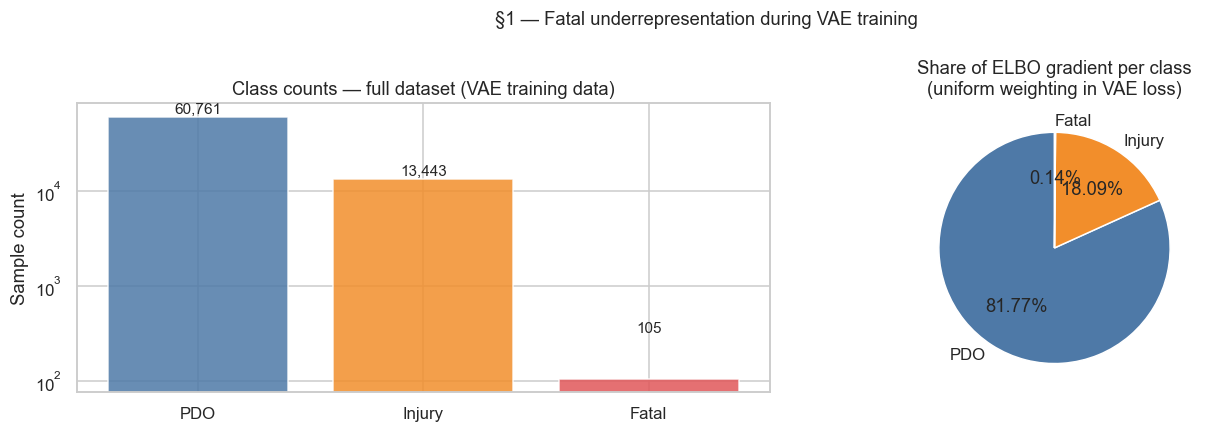


Fatal gradient share: 0.1413% of all ELBO updates
PDO / Fatal ratio   : 579x more PDO than Fatal


In [3]:
counts_all = {name: int((y_all == i).sum()) for i, name in enumerate(CLASS_NAMES)}
counts_train = {name: int((y_train == i).sum()) for i, name in enumerate(CLASS_NAMES)}

coverage = pd.DataFrame([
    (name,
     counts_all[name],
     f'{counts_all[name]/len(y_all):.2%}',
     counts_train[name],
     f'{counts_train[name]/len(y_train):.2%}',
     f'1 in {round(len(y_train)/max(counts_train[name],1))}')
    for name in CLASS_NAMES
], columns=['Class', 'N (full dataset)', '% of total', 'N (train split)', '% of train', 'Frequency'])

display(
    coverage.style
    .set_caption('Class distribution — VAE saw the full dataset (X_all) during training')
    .hide(axis='index')
)

# Visualise the imbalance
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ns   = [counts_all[n] for n in CLASS_NAMES]
bars = axes[0].bar(CLASS_NAMES, ns, color=CLASS_COLORS, alpha=0.85, edgecolor='white')
for bar, n in zip(bars, ns):
    axes[0].text(bar.get_x() + bar.get_width()/2, n + 200,
                 f'{n:,}', ha='center', va='bottom', fontsize=10)
axes[0].set_ylabel('Sample count')
axes[0].set_title('Class counts — full dataset (VAE training data)')
axes[0].set_yscale('log')

# Effective ELBO gradient contribution per class (proportional to count)
fracs = np.array([counts_all[n] for n in CLASS_NAMES]) / len(y_all)
axes[1].pie(fracs, labels=CLASS_NAMES, colors=CLASS_COLORS, autopct='%1.2f%%',
            startangle=90, wedgeprops=dict(edgecolor='white'))
axes[1].set_title('Share of ELBO gradient per class\n(uniform weighting in VAE loss)')

plt.suptitle('§1 — Fatal underrepresentation during VAE training', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nFatal gradient share: {fracs[2]:.4%} of all ELBO updates')
print(f'PDO / Fatal ratio   : {counts_all["PDO"] / counts_all["Fatal"]:.0f}x more PDO than Fatal')

---
## §2 — Did the encoder learn Fatal-specific structure?

We measure the **posterior uncertainty** the encoder assigns to each class.

- **σ² (posterior variance)**: if Fatal σ² ≈ 1 (prior), the encoder is not confident  
  about where Fatal samples belong in Z — it collapsed them back to the prior
- **KL divergence per class**: Fatal KL > PDO KL means the encoder found genuine  
  Fatal-specific structure worth encoding; Fatal KL ≈ 0 means it gave up
- **Active dimensions**: how many dims carry meaningful signal for Fatal specifically

=== Posterior quality per class ===
PDO       mean σ²=0.326  active dims (σ²<0.5)=5/8  collapsed (σ²>0.9)=0/8  mean KL=7.8789 nats
Injury    mean σ²=0.332  active dims (σ²<0.5)=5/8  collapsed (σ²>0.9)=0/8  mean KL=7.6283 nats
Fatal     mean σ²=0.331  active dims (σ²<0.5)=5/8  collapsed (σ²>0.9)=0/8  mean KL=7.6675 nats


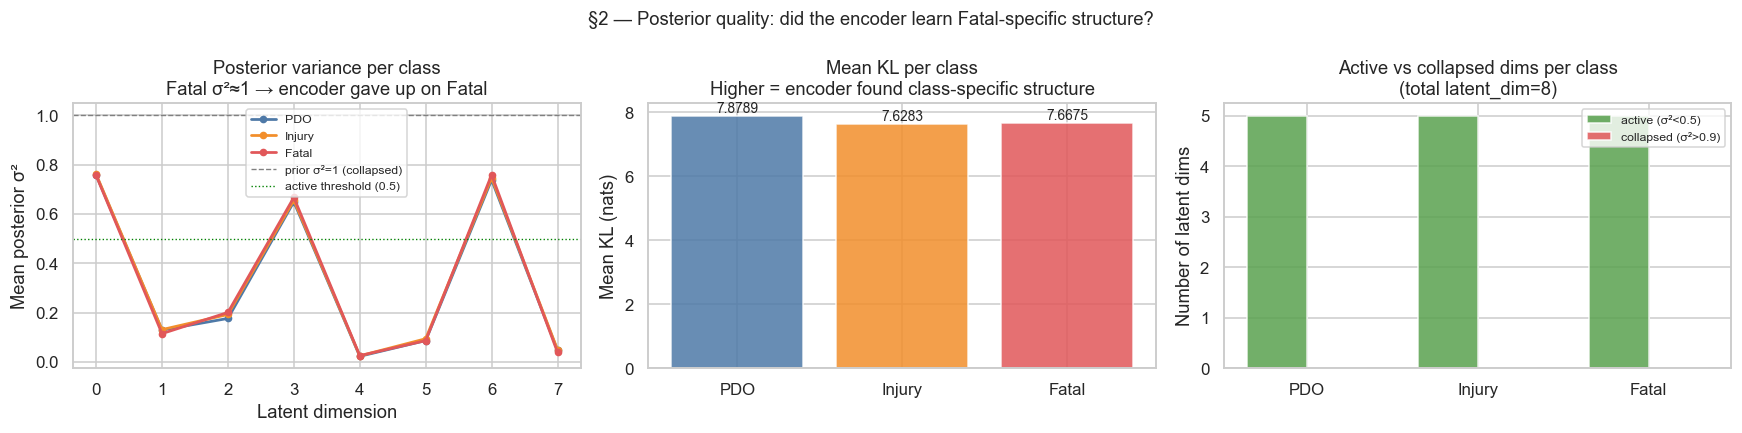

In [4]:
# Per-class posterior statistics
class_var   = np.stack([np.exp(lv[y_all == i]).mean(axis=0) for i in range(3)])  # (3, latent_dim)
class_mu    = np.stack([Z_all[y_all == i].mean(axis=0) for i in range(3)])       # (3, latent_dim)

kl_per_dim  = -0.5 * (1 + lv - Z_all**2 - np.exp(lv))          # (N, latent_dim)
kl_per_sample = kl_per_dim.sum(axis=1)                           # (N,)
class_kl    = [kl_per_sample[y_all == i].mean() for i in range(3)]

# Active dims per class (σ² < 0.5 threshold)
active_per_class = [(class_var[i] < 0.5).sum() for i in range(3)]
collapsed_per_class = [(class_var[i] > 0.9).sum() for i in range(3)]

print('=== Posterior quality per class ===')
for i, name in enumerate(CLASS_NAMES):
    print(f'{name:<8}  mean σ²={class_var[i].mean():.3f}  '
          f'active dims (σ²<0.5)={active_per_class[i]}/{latent_dim}  '
          f'collapsed (σ²>0.9)={collapsed_per_class[i]}/{latent_dim}  '
          f'mean KL={class_kl[i]:.4f} nats')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Posterior σ² per dim — all three classes overlaid
for i, (name, color) in enumerate(zip(CLASS_NAMES, CLASS_COLORS)):
    axes[0].plot(class_var[i], label=name, color=color, linewidth=1.8, marker='o', markersize=4)
axes[0].axhline(1.0, color='grey', linestyle='--', linewidth=0.9, label='prior σ²=1 (collapsed)')
axes[0].axhline(0.5, color='green', linestyle=':', linewidth=0.9, label='active threshold (0.5)')
axes[0].set_xlabel('Latent dimension')
axes[0].set_ylabel('Mean posterior σ²')
axes[0].set_title('Posterior variance per class\nFatal σ²≈1 → encoder gave up on Fatal')
axes[0].legend(fontsize=8)

# KL per class
bars = axes[1].bar(CLASS_NAMES, class_kl, color=CLASS_COLORS, alpha=0.85, edgecolor='white')
for bar, val in zip(bars, class_kl):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.002,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[1].set_ylabel('Mean KL (nats)')
axes[1].set_title('Mean KL per class\nHigher = encoder found class-specific structure')

# Active dim count per class
x = np.arange(3)
w = 0.35
axes[2].bar(x - w/2, active_per_class,   width=w, label='active (σ²<0.5)',   color='#59a14f', alpha=0.85)
axes[2].bar(x + w/2, collapsed_per_class, width=w, label='collapsed (σ²>0.9)', color='#e15759', alpha=0.85)
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Number of latent dims')
axes[2].set_title(f'Active vs collapsed dims per class\n(total latent_dim={latent_dim})')
axes[2].legend(fontsize=8)

plt.suptitle('§2 — Posterior quality: did the encoder learn Fatal-specific structure?', fontsize=12)
plt.tight_layout()
plt.show()

---
## §3 — Real vs CTGAN synthetic Fatal alignment in Z-space

The CTGAN augmenter generated synthetic Fatal rows in **X-space** then passed them  
through the **frozen encoder** to produce Z vectors.

**This is the critical test**: if real and synthetic Fatal rows land in the same Z region,  
the encoder understood Fatal crashes well enough that synthetics are indistinguishable.  
If they land in separate regions, the synthetic Z vectors don't resemble real Fatal Z vectors  
— the classifier is training on misleading augmented data.

We identify rows by index: the first `len(X_train)` rows of `X_train_augmented` are the  
original training rows (including real Fatal); the remaining rows are CTGAN synthetic Fatal.

Real Fatal in Z_train_aug    : 63
Synthetic Fatal in Z_train_aug: 11068
Total Fatal Z vectors        : 11131

Centroid distance  real Fatal vs synthetic Fatal : 0.6202
Centroid distance  real Fatal vs PDO             : 0.8217
Ratio (synth/PDO distance)                       : 0.755
  → Ratio < 0.5: synthetics are closer to real Fatal than to PDO (good)
  → Ratio > 1.0: synthetics are farther from real Fatal than PDO is (problem)


C:\Users\loren\AppData\Local\Temp\ipykernel_20440\63966877.py:78: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  plt.tight_layout()
c:\Users\loren\Documents\mlops-portfolio\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


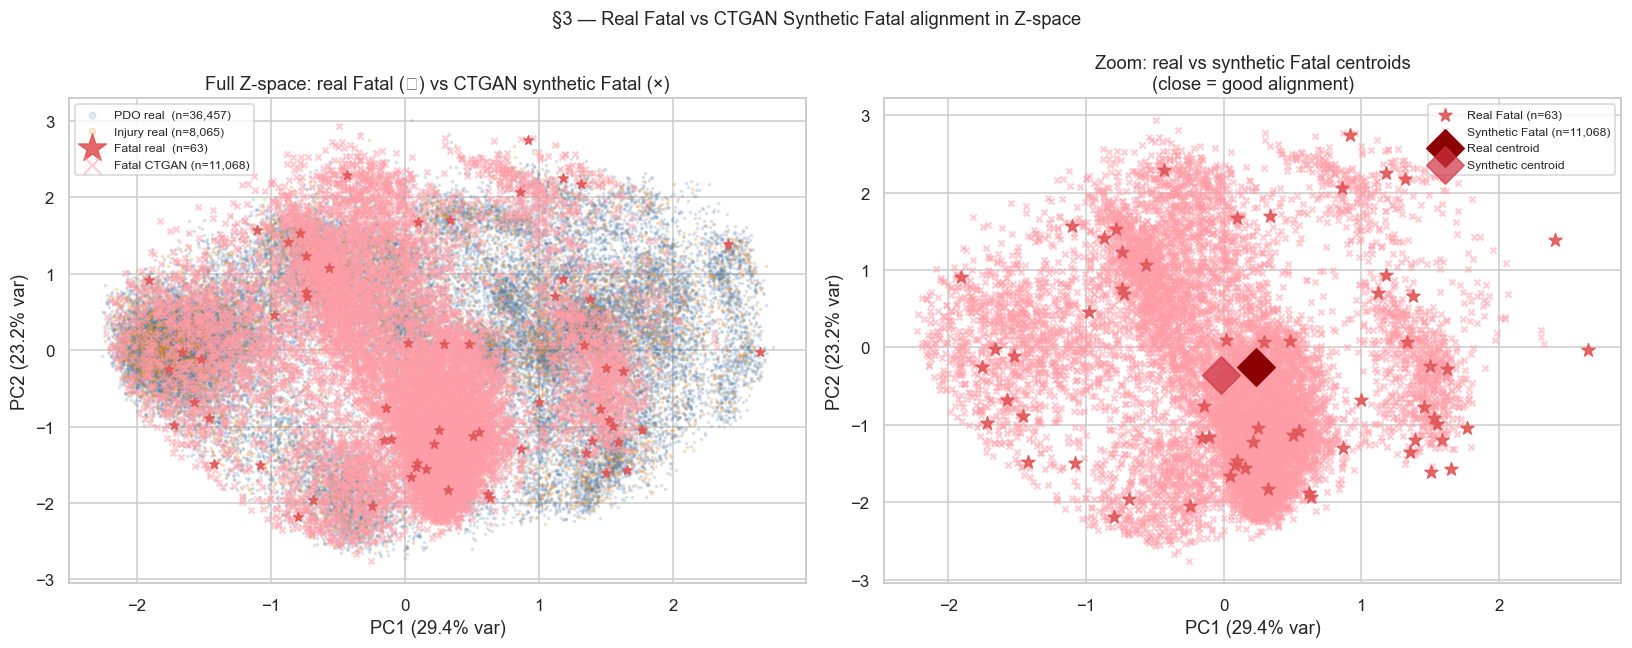

In [5]:
n_original = len(X_train)

# Split Z_train_aug into original rows and synthetic rows
Z_original   = Z_train_aug[:n_original]    # original training rows projected to Z
Z_synthetic  = Z_train_aug[n_original:]    # CTGAN synthetic Fatal rows projected to Z
y_original   = y_train_aug[:n_original]
y_synthetic  = y_train_aug[n_original:]    # all should be Fatal (class 2)

assert (y_synthetic == 2).all(), 'Unexpected: synthetic rows contain non-Fatal labels'

Z_real_fatal = Z_original[y_original == 2]  # real Fatal Z vectors in train
Z_real_pdo   = Z_original[y_original == 0]  # real PDO for reference

print(f'Real Fatal in Z_train_aug    : {len(Z_real_fatal)}')
print(f'Synthetic Fatal in Z_train_aug: {len(Z_synthetic)}')
print(f'Total Fatal Z vectors        : {len(Z_real_fatal) + len(Z_synthetic)}')

# PCA on all Z_train_aug to project everything into the same 2D space
pca   = PCA(n_components=2, random_state=42)
Z_pca = pca.fit_transform(Z_train_aug)
var_exp = pca.explained_variance_ratio_ * 100

pca_orig = Z_pca[:n_original]
pca_synth = Z_pca[n_original:]

# Centroid distance (in original Z-space) between real and synthetic Fatal
centroid_real  = Z_real_fatal.mean(axis=0)
centroid_synth = Z_synthetic.mean(axis=0)
centroid_pdo   = Z_real_pdo.mean(axis=0)

dist_real_synth = float(np.linalg.norm(centroid_real - centroid_synth))
dist_real_pdo   = float(np.linalg.norm(centroid_real - centroid_pdo))

print(f'\nCentroid distance  real Fatal vs synthetic Fatal : {dist_real_synth:.4f}')
print(f'Centroid distance  real Fatal vs PDO             : {dist_real_pdo:.4f}')
print(f'Ratio (synth/PDO distance)                       : {dist_real_synth/dist_real_pdo:.3f}')
print(f'  → Ratio < 0.5: synthetics are closer to real Fatal than to PDO (good)')
print(f'  → Ratio > 1.0: synthetics are farther from real Fatal than PDO is (problem)')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Full Z-space: PDO vs real Fatal vs synthetic Fatal
axes[0].scatter(pca_orig[y_original == 0, 0], pca_orig[y_original == 0, 1],
                s=2, alpha=0.15, color='#4e79a7', label=f'PDO real  (n={len(Z_real_pdo):,})')
axes[0].scatter(pca_orig[y_original == 1, 0], pca_orig[y_original == 1, 1],
                s=2, alpha=0.2, color='#f28e2b', label=f'Injury real (n={(y_original==1).sum():,})')
axes[0].scatter(pca_orig[y_original == 2, 0], pca_orig[y_original == 2, 1],
                s=40, alpha=0.9, color='#e15759', marker='*',
                label=f'Fatal real  (n={len(Z_real_fatal)})', zorder=5)
axes[0].scatter(pca_synth[:, 0], pca_synth[:, 1],
                s=15, alpha=0.5, color='#ff9da7', marker='x',
                label=f'Fatal CTGAN (n={len(Z_synthetic):,})', zorder=4)
axes[0].set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)')
axes[0].set_title('Full Z-space: real Fatal (★) vs CTGAN synthetic Fatal (×)')
axes[0].legend(markerscale=3, fontsize=8)

# Zoom: real Fatal vs synthetic Fatal only
axes[1].scatter(pca_orig[y_original == 2, 0], pca_orig[y_original == 2, 1],
                s=80, alpha=0.9, color='#e15759', marker='*',
                label=f'Real Fatal (n={len(Z_real_fatal)})', zorder=5)
axes[1].scatter(pca_synth[:, 0], pca_synth[:, 1],
                s=15, alpha=0.5, color='#ff9da7', marker='x',
                label=f'Synthetic Fatal (n={len(Z_synthetic):,})', zorder=4)
# Mark centroids
pca_cr = pca.transform(centroid_real.reshape(1, -1))[0]
pca_cs = pca.transform(centroid_synth.reshape(1, -1))[0]
axes[1].scatter(*pca_cr, s=300, color='darkred',  marker='D', zorder=6, label='Real centroid')
axes[1].scatter(*pca_cs, s=300, color='#cc3344',  marker='D', zorder=6, label='Synthetic centroid', alpha=0.7)
axes[1].plot([pca_cr[0], pca_cs[0]], [pca_cr[1], pca_cs[1]],
             color='black', linestyle='--', linewidth=1.2)
axes[1].set_xlabel(f'PC1 ({var_exp[0]:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]:.1f}% var)')
axes[1].set_title('Zoom: real vs synthetic Fatal centroids\n(close = good alignment)')
axes[1].legend(fontsize=8)

plt.suptitle('§3 — Real Fatal vs CTGAN Synthetic Fatal alignment in Z-space', fontsize=12)
plt.tight_layout()
plt.show()

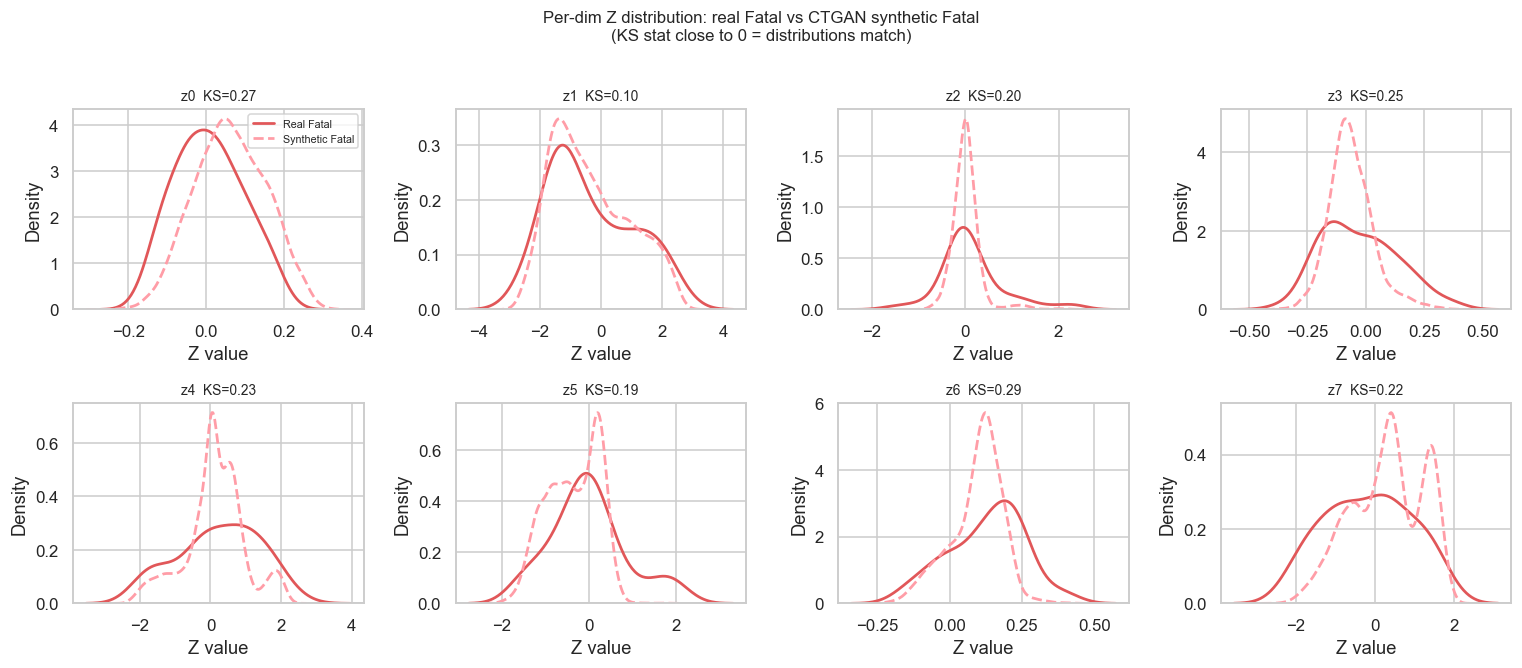

Dims where real vs synthetic KS < 0.10 (well aligned): 0 / 8
Dims where real vs synthetic KS > 0.30 (misaligned)  : 0 / 8


dim,ks_stat,p_value
z6,0.2867,4.4665e-05
z0,0.2661,1.9910e-04
z3,0.2531,4.8248e-04
z4,0.2300,2.0574e-03
z7,0.2231,3.1045e-03
z2,0.1952,1.4103e-02
z5,0.1911,1.7241e-02
z1,0.1021,4.9538e-01


In [6]:
# Per-dim KDE: real Fatal vs synthetic Fatal — do their Z distributions match?
ncols = min(latent_dim, 4)
nrows = (latent_dim + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 3))
axes_flat = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

ks_real_synth = []
for d in range(latent_dim):
    ax = axes_flat[d]
    real_vals  = Z_real_fatal[:, d]
    synth_vals = Z_synthetic[:, d]
    ks = stats.ks_2samp(real_vals, synth_vals)
    ks_real_synth.append({'dim': f'z{d}', 'ks_stat': ks.statistic, 'p_value': ks.pvalue})

    sns.kdeplot(real_vals,  ax=ax, color='#e15759', linewidth=1.8, label='Real Fatal')
    sns.kdeplot(synth_vals, ax=ax, color='#ff9da7', linewidth=1.8, linestyle='--', label='Synthetic Fatal')
    ax.set_title(f'z{d}  KS={ks.statistic:.2f}', fontsize=9)
    ax.set_xlabel('Z value')
    if d == 0:
        ax.legend(fontsize=7)
    else:
        leg = ax.get_legend()
        if leg: leg.remove()

for ax in axes_flat[latent_dim:]:
    ax.set_visible(False)

fig.suptitle('Per-dim Z distribution: real Fatal vs CTGAN synthetic Fatal\n'
             '(KS stat close to 0 = distributions match)', fontsize=11, y=1.01)
plt.tight_layout()
plt.show()

ks_df = pd.DataFrame(ks_real_synth).sort_values('ks_stat', ascending=False).reset_index(drop=True)
print(f'Dims where real vs synthetic KS < 0.10 (well aligned): {(ks_df["ks_stat"] < 0.10).sum()} / {latent_dim}')
print(f'Dims where real vs synthetic KS > 0.30 (misaligned)  : {(ks_df["ks_stat"] > 0.30).sum()} / {latent_dim}')
display(
    ks_df.style
    .format({'ks_stat': '{:.4f}', 'p_value': '{:.4e}'})
    .background_gradient(subset=['ks_stat'], cmap='YlOrRd')
    .set_caption('KS test: real Fatal vs synthetic Fatal per latent dimension')
    .hide(axis='index')
)

---
## §4 — Fatal separability from PDO and Injury in Z-space

Even if the encoder learned Fatal structure imperfectly, the classifier can still work  
if Fatal Z vectors occupy a **distinct region** from PDO and Injury.

We measure separability two ways:
- **Normalised centroid distance**: |Fatal mean − PDO mean| / Fatal std per dim  
  (> 1 means Fatal and PDO are more than one Fatal-std apart in that dim)
- **Overlap coefficient**: fraction of PDO Z vectors that fall within the Fatal cluster's  
  bounding box (high overlap = classifier has little signal)

Avg normalised separation Fatal vs PDO    : 0.583  (>1 is good)
Avg normalised separation Fatal vs Injury : 0.500  (>1 is good)
PDO overlap inside Fatal 2σ box           : 24.20%  (<10% is good)
Dims with Fatal-PDO separation > 1σ       : 3 / 8


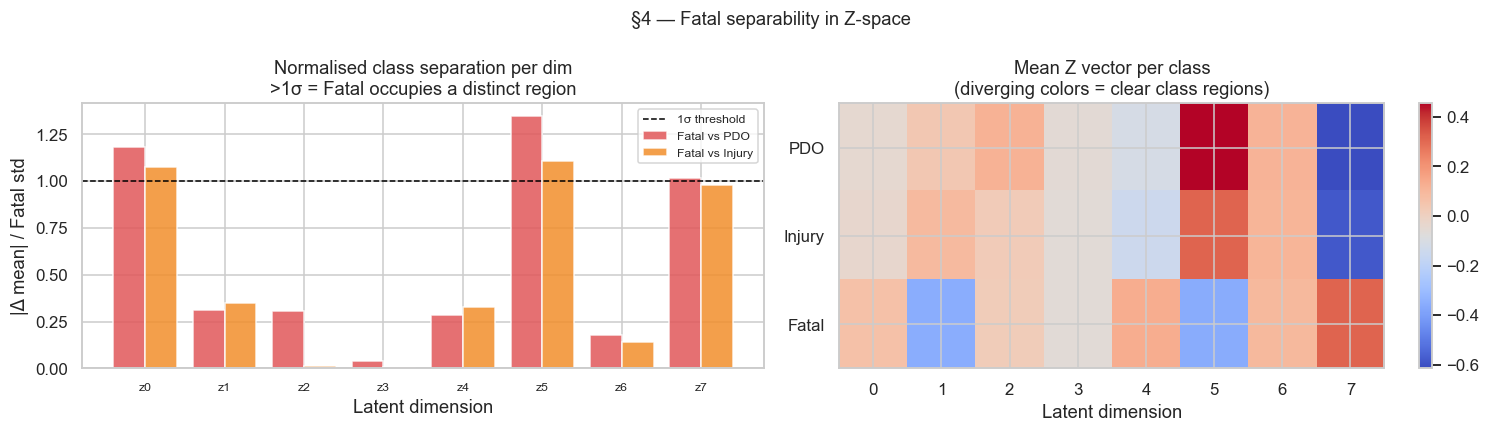

In [7]:
# Use all Fatal Z vectors (real + synthetic) — this is what the classifier sees
Z_fatal_all = np.vstack([Z_real_fatal, Z_synthetic])

fatal_mean = Z_fatal_all.mean(axis=0)
fatal_std  = Z_fatal_all.std(axis=0, ddof=1)
pdo_mean   = Z_real_pdo.mean(axis=0)
inj_mean   = Z_train_aug[y_train_aug == 1].mean(axis=0)

sep_fatal_pdo = np.abs(fatal_mean - pdo_mean) / np.maximum(fatal_std, 1e-6)
sep_fatal_inj = np.abs(fatal_mean - inj_mean) / np.maximum(fatal_std, 1e-6)

# Overlap: fraction of PDO samples inside Fatal's [mean-2std, mean+2std] bounding box
lower = fatal_mean - 2 * fatal_std
upper = fatal_mean + 2 * fatal_std
inside = np.all((Z_real_pdo >= lower) & (Z_real_pdo <= upper), axis=1)
overlap_frac = inside.mean()

print(f'Avg normalised separation Fatal vs PDO    : {sep_fatal_pdo.mean():.3f}  (>1 is good)')
print(f'Avg normalised separation Fatal vs Injury : {sep_fatal_inj.mean():.3f}  (>1 is good)')
print(f'PDO overlap inside Fatal 2σ box           : {overlap_frac:.2%}  (<10% is good)')
print(f'Dims with Fatal-PDO separation > 1σ       : {(sep_fatal_pdo > 1).sum()} / {latent_dim}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Normalised separation per dim
x = np.arange(latent_dim)
axes[0].bar(x - 0.2, sep_fatal_pdo, width=0.4, label='Fatal vs PDO',    color='#e15759', alpha=0.85)
axes[0].bar(x + 0.2, sep_fatal_inj, width=0.4, label='Fatal vs Injury', color='#f28e2b', alpha=0.85)
axes[0].axhline(1.0, color='black', linestyle='--', linewidth=1.0, label='1σ threshold')
axes[0].set_xlabel('Latent dimension')
axes[0].set_ylabel('|Δ mean| / Fatal std')
axes[0].set_title('Normalised class separation per dim\n>1σ = Fatal occupies a distinct region')
axes[0].legend(fontsize=8)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'z{i}' for i in x], fontsize=8)

# Mean latent vector per class (heatmap)
class_means_aug = np.stack([
    Z_train_aug[y_train_aug == i].mean(axis=0) for i in range(3)
])
im = axes[1].imshow(class_means_aug, aspect='auto', cmap='coolwarm')
axes[1].set_yticks(range(3))
axes[1].set_yticklabels(CLASS_NAMES)
axes[1].set_xlabel('Latent dimension')
axes[1].set_title('Mean Z vector per class\n(diverging colors = clear class regions)')
plt.colorbar(im, ax=axes[1])

plt.suptitle('§4 — Fatal separability in Z-space', fontsize=12)
plt.tight_layout()
plt.show()

---
## §5 — Verdict

**Decision criteria**:

| Metric | Healthy | Borderline | Problem |
|---|---|---|---|
| Fatal active dims (σ²<0.5) | ≥ 3 | 1–2 | 0 |
| Fatal KL vs PDO KL | Fatal > PDO | Fatal ≈ PDO | Fatal < PDO |
| Centroid dist (synth/PDO ratio) | < 0.5 | 0.5–1.0 | > 1.0 |
| KS real vs synth Fatal (dims aligned) | ≥ 50% dims KS<0.10 | 25–50% | < 25% |
| Fatal-PDO normalised separation | ≥ 1σ in ≥ 3 dims | 1–2 dims | 0 dims |
| PDO overlap in Fatal 2σ box | < 10% | 10–30% | > 30% |

**If healthy**: the VAE learned adequate Fatal structure from 105 samples; CTGAN synthetics are well-placed; no architectural change needed.  
**If borderline/problem**: consider training the VAE with **oversampled real Fatal rows** (repeat Fatal rows to increase their gradient share) — this keeps the real-data-only principle and does not require changing the DAG.

In [8]:
n_active_fatal     = int((class_var[2] < 0.5).sum())
fatal_kl_vs_pdo    = class_kl[2] > class_kl[0]
ratio_synth_pdo    = dist_real_synth / dist_real_pdo
pct_ks_aligned     = float((ks_df['ks_stat'] < 0.10).sum()) / latent_dim
n_dims_sep_1sigma  = int((sep_fatal_pdo > 1).sum())

def grade(val, good, ok):
    if val >= good:  return '✅ Healthy'
    if val >= ok:    return '⚠️  Borderline'
    return '❌ Problem'

def grade_inv(val, good, ok):   # lower is better
    if val <= good:  return '✅ Healthy'
    if val <= ok:    return '⚠️  Borderline'
    return '❌ Problem'

verdict = pd.DataFrame([
    ('Fatal active dims (σ²<0.5)',
     f'{n_active_fatal} / {latent_dim}',
     grade(n_active_fatal, 3, 1)),
    ('Fatal KL > PDO KL',
     'Yes' if fatal_kl_vs_pdo else 'No',
     '✅ Healthy' if fatal_kl_vs_pdo else '❌ Problem'),
    ('Centroid dist ratio (synth/PDO)',
     f'{ratio_synth_pdo:.3f}',
     grade_inv(ratio_synth_pdo, 0.5, 1.0)),
    ('KS-aligned dims real vs synth Fatal',
     f'{pct_ks_aligned:.0%} ({int(pct_ks_aligned*latent_dim)}/{latent_dim} dims KS<0.10)',
     grade(pct_ks_aligned, 0.5, 0.25)),
    ('Fatal-PDO separation > 1σ',
     f'{n_dims_sep_1sigma} / {latent_dim} dims',
     grade(n_dims_sep_1sigma, 3, 1)),
    ('PDO overlap in Fatal 2σ box',
     f'{overlap_frac:.2%}',
     grade_inv(overlap_frac, 0.10, 0.30)),
], columns=['Metric', 'Value', 'Status'])

display(
    verdict.style
    .set_caption('§5 — VAE Fatal representation audit: verdict')
    .hide(axis='index')
)

n_problems     = (verdict['Status'].str.startswith('❌')).sum()
n_borderline   = (verdict['Status'].str.startswith('⚠️')).sum()

print()
if n_problems == 0 and n_borderline == 0:
    print('OVERALL: ✅ HEALTHY — VAE learned adequate Fatal structure from 105 samples.')
    print('         CTGAN synthetics are well-aligned with real Fatals in Z-space.')
    print('         No architectural change required.')
elif n_problems == 0:
    print('OVERALL: ⚠️  BORDERLINE — Fatal representation is marginal.')
    print('         Consider retraining VAE with oversampled Fatal rows (repeat Fatal')
    print('         rows ~10x in training batch) before implementing KL annealing (T106).')
else:
    print('OVERALL: ❌ PROBLEM — Fatal Z representation is poor.')
    print('         Recommended fix: retrain VAE with Fatal rows oversampled in the')
    print('         training DataLoader (weighted sampler, weight = N/class_count).')
    print('         This keeps real-data-only principle and does not change the DAG.')

Metric,Value,Status
Fatal active dims (σ²<0.5),5 / 8,✅ Healthy
Fatal KL > PDO KL,No,❌ Problem
Centroid dist ratio (synth/PDO),0.755,⚠️ Borderline
KS-aligned dims real vs synth Fatal,0% (0/8 dims KS<0.10),❌ Problem
Fatal-PDO separation > 1σ,3 / 8 dims,✅ Healthy
PDO overlap in Fatal 2σ box,24.20%,⚠️ Borderline



OVERALL: ❌ PROBLEM — Fatal Z representation is poor.
         Recommended fix: retrain VAE with Fatal rows oversampled in the
         training DataLoader (weighted sampler, weight = N/class_count).
         This keeps real-data-only principle and does not change the DAG.
